Best Route: [7, 2, 8, 3, 5, 0, 4, 1, 6, 9, 7]
Shortest Distance: 2.9030677377778753


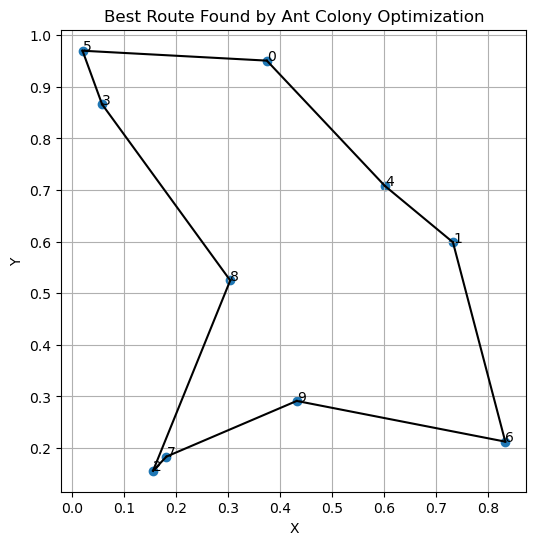

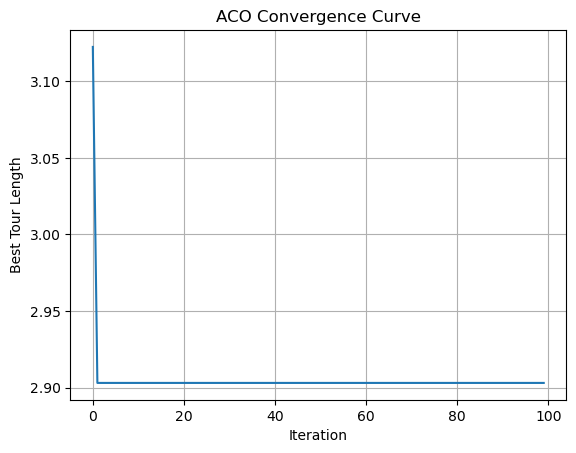

In [1]:
# -------------------------------
# Imports (FIXED)
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
import random

# -------------------------------
# Step 1: Define TSP Problem
# -------------------------------
np.random.seed(42)

num_cities = 10
cities = np.random.rand(num_cities, 2)  # (x, y)

def distance(c1, c2):
    return np.linalg.norm(c1 - c2)

# Distance matrix
dist_matrix = np.zeros((num_cities, num_cities))

for i in range(num_cities):
    for j in range(num_cities):
        dist_matrix[i][j] = distance(cities[i], cities[j])

# -------------------------------
# Step 2: ACO Parameters
# -------------------------------
num_ants = 20
num_iterations = 100

alpha = 1.0
beta = 5.0
evaporation = 0.5
Q = 100

pheromone = np.ones((num_cities, num_cities))

best_route = None
best_length = float('inf')
best_history = []

# -------------------------------
# Step 3: ACO Algorithm
# -------------------------------
for iteration in range(num_iterations):

    all_routes = []
    all_lengths = []

    for ant in range(num_ants):

        start = random.randint(0, num_cities - 1)
        route = [start]
        visited = set(route)

        while len(route) < num_cities:

            current = route[-1]
            probabilities = []

            for city in range(num_cities):

                if city not in visited:
                    tau = pheromone[current][city] ** alpha
                    eta = (1 / dist_matrix[current][city]) ** beta
                    probabilities.append(tau * eta)
                else:
                    probabilities.append(0)

            probabilities = np.array(probabilities)
            probabilities /= probabilities.sum()

            next_city = np.random.choice(range(num_cities), p=probabilities)

            route.append(next_city)
            visited.add(next_city)

        route.append(start)  # return to start

        length = sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

        all_routes.append(route)
        all_lengths.append(length)

        if length < best_length:
            best_length = length
            best_route = route

    # Pheromone evaporation
    pheromone *= (1 - evaporation)

    # Pheromone update
    for route, length in zip(all_routes, all_lengths):
        for i in range(len(route)-1):
            pheromone[route[i]][route[i+1]] += Q / length

    best_history.append(best_length)

# -------------------------------
# Step 4: Results (SAME AS PDF)
# -------------------------------
print("Best Route:", best_route)
print("Shortest Distance:", best_length)

# -------------------------------
# Step 5: Plot Best Route
# -------------------------------
plt.figure(figsize=(6, 6))

for i in range(len(best_route)-1):
    c1 = cities[best_route[i]]
    c2 = cities[best_route[i+1]]
    plt.plot([c1[0], c2[0]], [c1[1], c2[1]], 'k-')

plt.scatter(cities[:, 0], cities[:, 1])

for i, city in enumerate(cities):
    plt.text(city[0], city[1], f"{i}")

plt.title("Best Route Found by Ant Colony Optimization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()

plt.show()

# -------------------------------
# Step 6: Convergence Plot
# -------------------------------
plt.figure()

plt.plot(best_history)
plt.xlabel("Iteration")
plt.ylabel("Best Tour Length")
plt.title("ACO Convergence Curve")
plt.grid()

plt.show()